# Occurrence-rate KDE maps with fitted desert boundaries

Reproduces the weighted-KDE occurrence maps and the fitted desert
boundaries (median + 16-84% bands) for F/G/K/FGK stars from
`wkde_boundary_release.npz`. 

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt


In [2]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = [3.3, 2.5]
plt.rcParams["axes.labelsize"] = 5
plt.rcParams["xtick.labelsize"] = 5
plt.rcParams["ytick.labelsize"] = 5
plt.rcParams["legend.fontsize"] = 5
plt.rcParams["font.size"] = 5
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "DejaVu Sans",
    "Arial",
    "Helvetica",
    "Lucida Grande",
    "Verdana",
    "Geneva",
    "Lucid",
    "Avant Garde",
    "sans-serif",
]
plt.rcParams["mathtext.fontset"] = "dejavusans"
plt.rcParams["axes.linewidth"] = 0.5
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["lines.linewidth"] = 1.0
plt.rcParams["lines.markersize"] = 3

In [3]:
# Load wKDE and boundary data.
data = np.load("wkde_boundary_release.npz")
# data contains the following arrays:
# - R_up, R_lo: radius grid for the upper and lower boundaries
# - P_up_F, P_up_G, P_up_K, P_up_FGK: 16th, 50th, 84th percentile curves for the upper boundary for each spectral type
# - P_lo_F, P_lo_G, P_lo_K, P_lo_FGK: 16th, 50th, 84th percentile curves for the lower boundary for each spectral type
# - kde_Z_F, kde_Z_G, kde_Z_K, kde_Z_FGK: 2D KDE occurrence maps for each spectral type

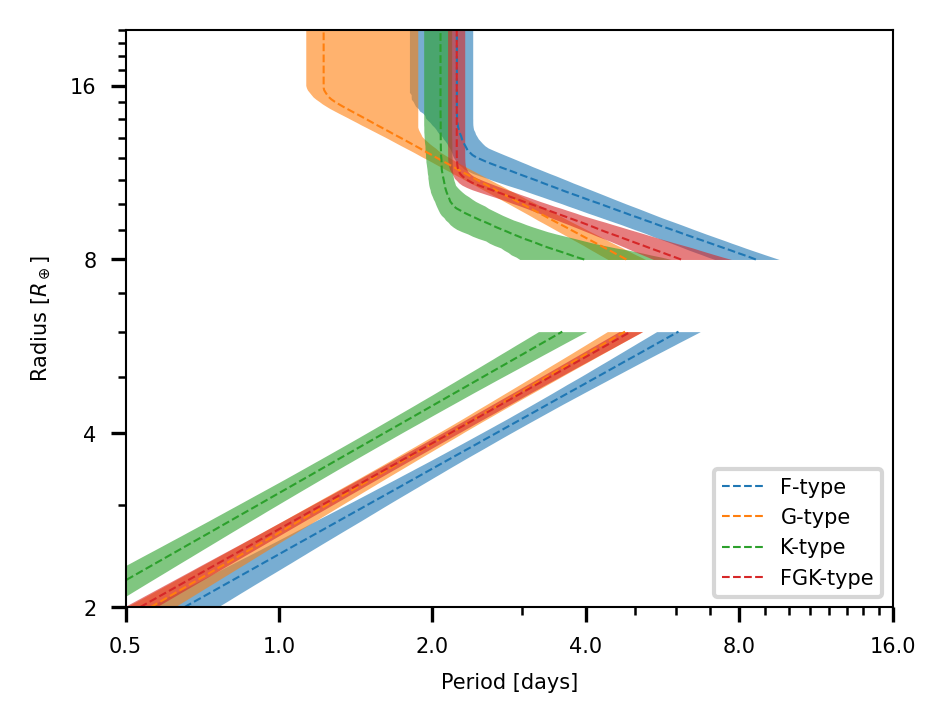

In [4]:
def _band(ax, R, P16, P50, P84, color="r", label=None):
    ax.fill_betweenx(R, P16, P84, color=color, alpha=0.6, lw=0)
    ax.plot(P50, R, c=color, ls="--", lw=0.5, label=label)

fig, ax = plt.subplots()
for t, c in zip(["F", "G", "K", "FGK"], ["C0", "C1", "C2", "C3"]):
    _band(ax, data["R_up"], *data[f"P_up_{t}"], color=c, label=f"{t}-type")  # upper desert boundary
    _band(ax, data["R_lo"], *data[f"P_lo_{t}"], color=c)  # lower 2D power-law contour
    # plt.loglog(data[f'P_up_{t}'][1], data['R_up'], ls='--', lw=1, label=t, c=c)
    # plt.loglog(data[f'P_lo_{t}'][1], data['R_lo'], ls='--', lw=1, c=c)

plt.legend(loc="lower right")

ax = plt.gca()
ax.set(xscale="log", yscale="log", xlim=(0.5, 16), ylim=(2, 20), xlabel="Period [days]", ylabel="Radius [$R_\\oplus$]")
ax.set_xticks([0.5, 1, 2, 4, 8, 16])
ax.set_yticks([2, 4, 8, 16])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))


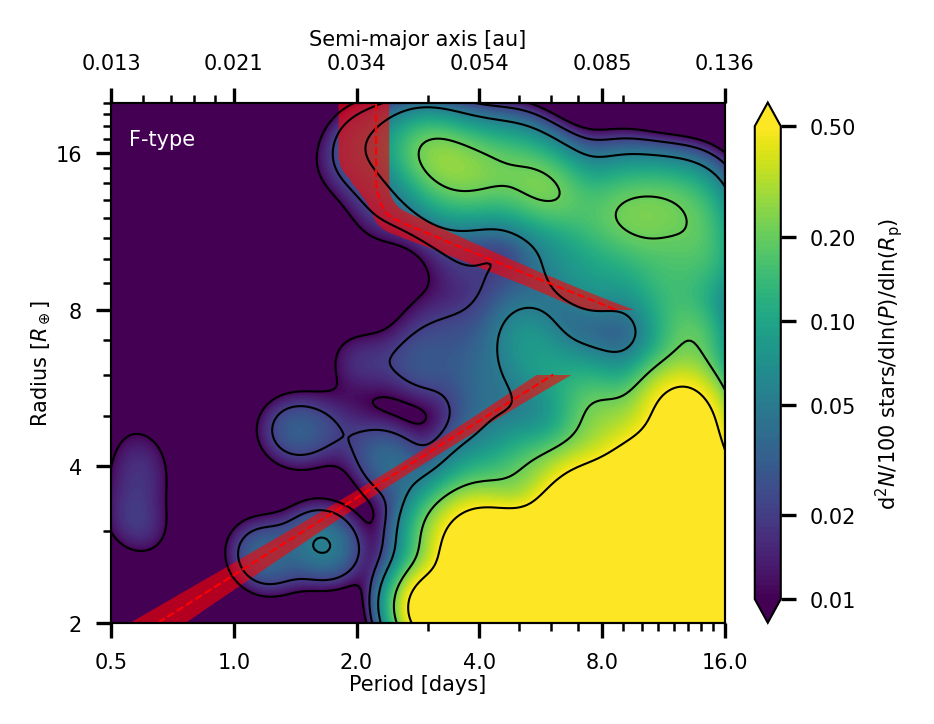

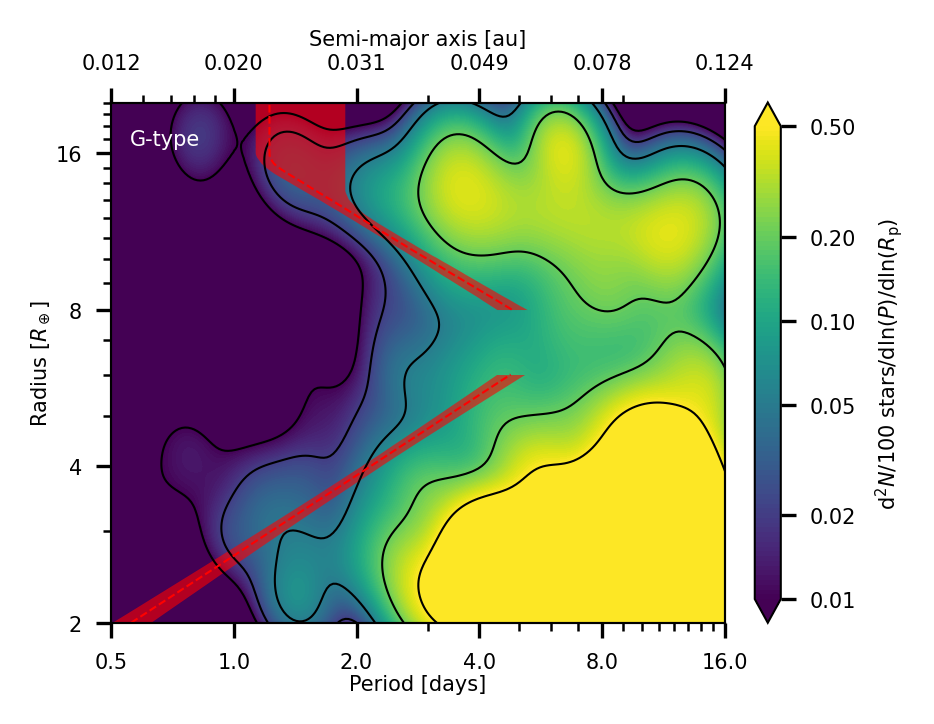

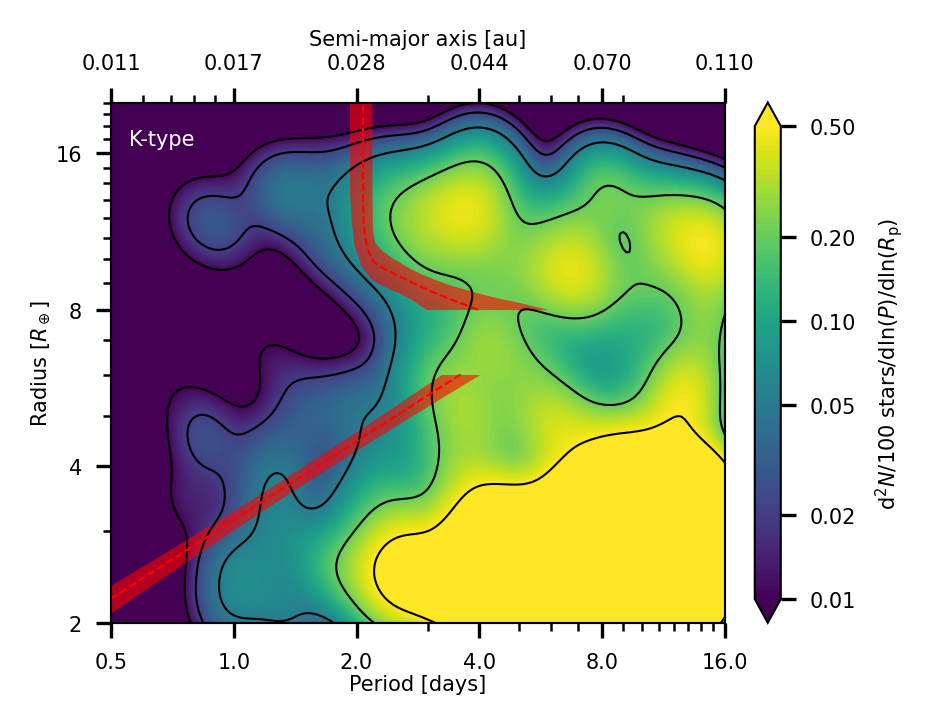

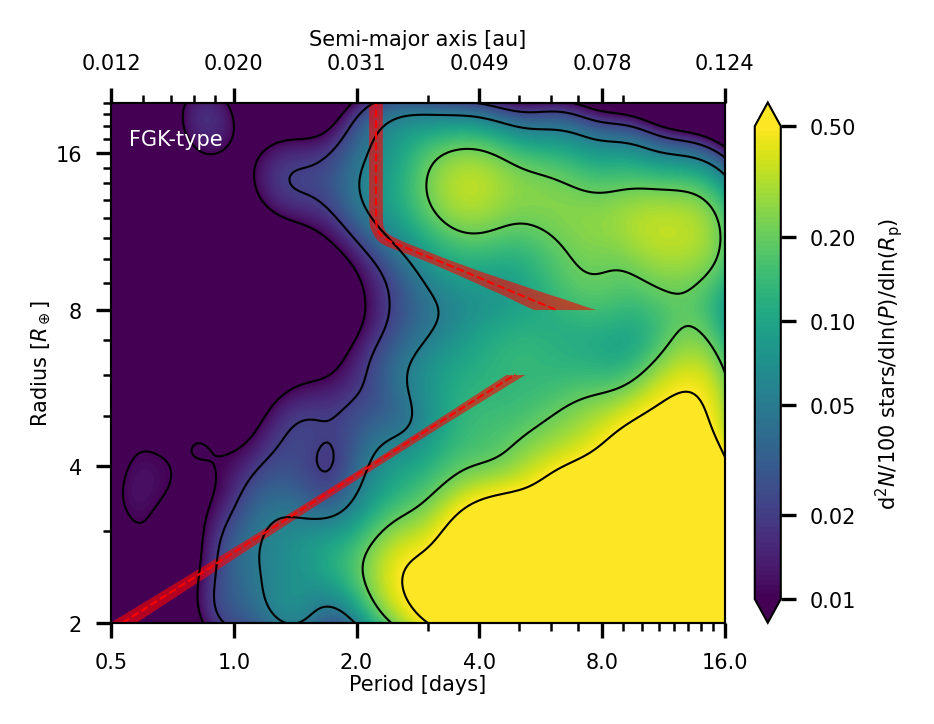

In [5]:
M_star_types = {
    "F": 1.3,
    "G": 1.0,
    "K": 0.7,
    "FGK": 1.0,
}  # solar masses, for the a-axis

for t in ["F", "G", "K", "FGK"]:
    plt.figure(constrained_layout=True, figsize=(3, 2.3))
    con = plt.contourf(
        10 ** data["lgP_axis"],
        10 ** data["lgR_axis"],
        data[f"kde_Z_{t}"].T,
        levels=np.logspace(np.log10(0.01), np.log10(0.5), 100),
        cmap="viridis",
        norm=matplotlib.colors.LogNorm(vmax=0.5, vmin=0.01, clip=False),
        extend="both",
    )
    plt.colorbar(
        con,
        ticks=[0.01, 0.02, 0.05, 0.1, 0.2, 0.5],
        format="%.2f",
        label="$\\mathrm{d}^2 N/ \\mathrm{100\\ stars} / \\mathrm{d} \\ln(P) / \\mathrm{d} \\ln(R_\\mathrm{p})$",
        pad=0.0001,
    )
    contour = plt.contour(con, levels=[0.01, 0.02, 0.05, 0.2, 0.5], colors='k', linewidths=0.5)
    ax = plt.gca()

    _band(ax, data["R_up"], *data[f"P_up_{t}"])  # upper desert boundary
    _band(ax, data["R_lo"], *data[f"P_lo_{t}"])  # lower 2D power-law contour
    
    # p16, p50, p84 = data[f"P_mid_{t}"]  # 6-8 R: broken power-law break
    # _band(ax, np.array([6.0, 8.0]), [p16] * 2, [p50] * 2, [p84] * 2)

    ax.set(
        xscale="log",
        yscale="log",
        xlim=(0.5, 16),
        ylim=(2, 20),
        xlabel="Period [days]",
        ylabel="Radius [$R_\\oplus$]",
    )
    ax.set_xticks([0.5, 1, 2, 4, 8, 16])
    ax.set_yticks([2, 4, 8, 16])
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
        axis.set_minor_formatter(matplotlib.ticker.NullFormatter())
        axis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
    ax.xaxis.labelpad = 0.5
    ax.yaxis.labelpad = 0.5
    ax.text(0.03, 0.95, f"{t}-type", transform=ax.transAxes, va="top", color="w")

    # top axis: semi-major axis corresponding to the period ticks
    P_ticks = np.array([0.5, 1, 2, 4, 8, 16])
    a_AU = (P_ticks / 365.25) ** (2 / 3) * M_star_types[t] ** (1 / 3)
    ax2 = ax.twiny()
    ax2.set_xscale("log")
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(P_ticks)
    ax2.set_xticklabels([f"{a:.3f}" for a in a_AU])
    ax2.set_xlabel("Semi-major axis [au]", labelpad=2)


Text(0.5, 0, 'Semi-major axis [au]')

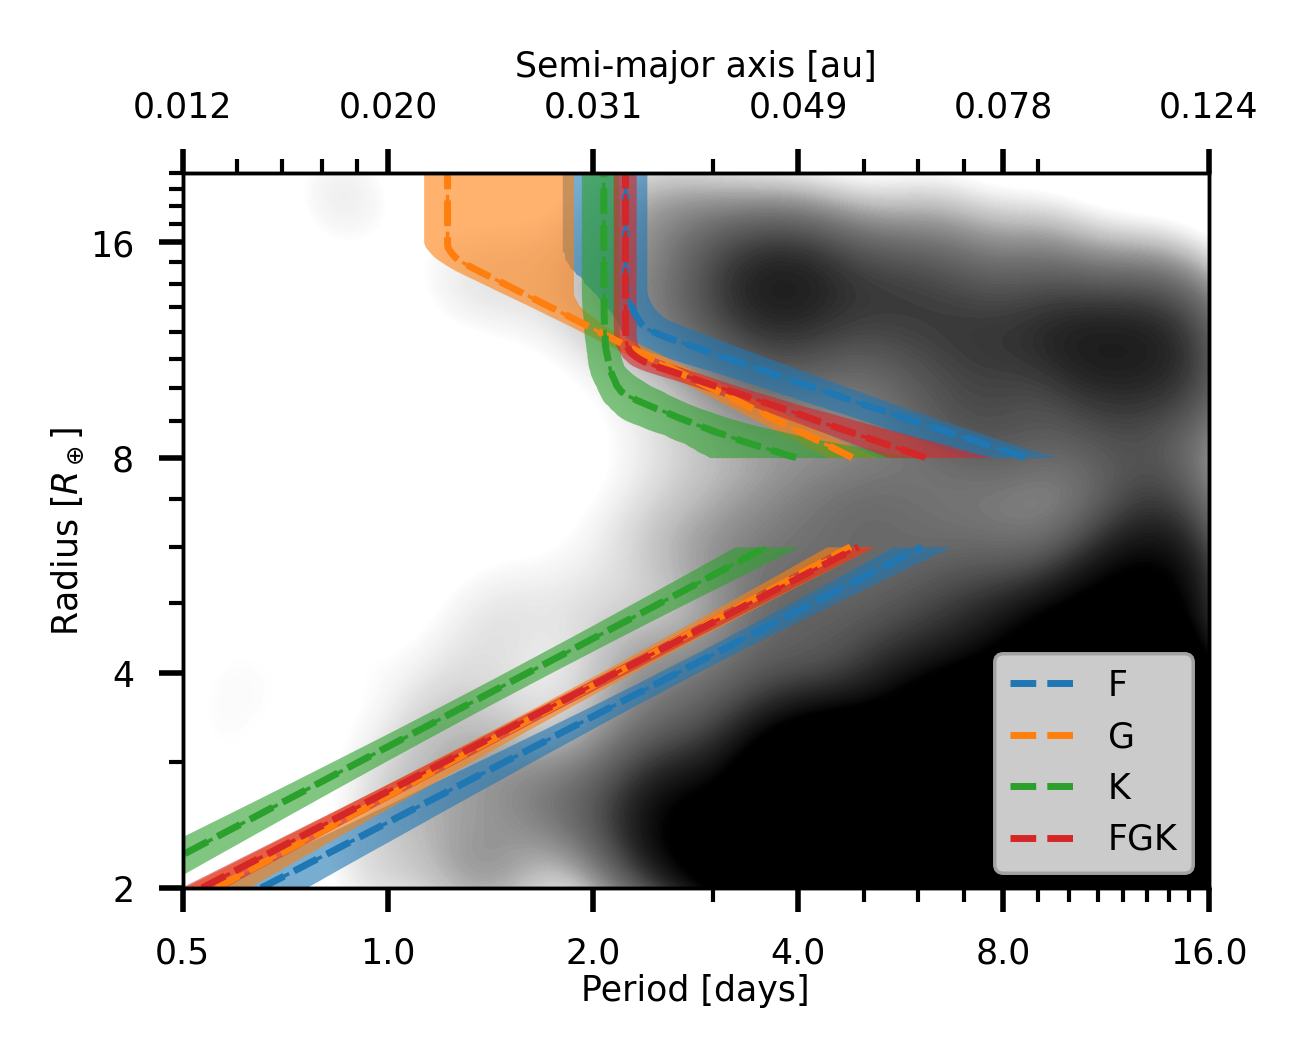

In [6]:
plt.figure(constrained_layout=True, dpi=500, figsize=(2.5, 2))
con = plt.contourf(
    10 ** data["lgP_axis"], 10 ** data["lgR_axis"], data[f"kde_Z_FGK"].T,
    levels=np.logspace(np.log10(0.01), np.log10(0.5), 100),
    cmap="Greys",
    norm=matplotlib.colors.LogNorm(vmax=0.5, vmin=0.01, clip=False),
    extend="both",
)

ax = plt.gca()

ax.set(xscale="log", yscale="log", xlim=(0.5, 16), ylim=(2, 20),
    xlabel="Period [days]", ylabel="Radius [$R_\\oplus$]")
ax.set_xticks([0.5, 1, 2, 4, 8, 16])
ax.set_yticks([2, 4, 8, 16])
for axis in (ax.xaxis, ax.yaxis):
    axis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
    axis.set_minor_formatter(matplotlib.ticker.NullFormatter())
    axis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
# ax.text(0.03, 0.95, f"{t}-type", transform=ax.transAxes, va="top", color="w")

# top axis: semi-major axis corresponding to the period ticks
P_ticks = np.array([0.5, 1, 2, 4, 8, 16])
a_AU = (P_ticks / 365.25) ** (2 / 3) * M_star_types["FGK"] ** (1 / 3)

for t, c in zip(["F", "G", "K", "FGK"], ["C0", "C1", "C2", "C3"]):
    plt.loglog(data[f'P_up_{t}'][1], data['R_up'], ls='--', lw=1, label=t, c=c)
    plt.loglog(data[f'P_lo_{t}'][1], data['R_lo'], ls='--', lw=1, c=c)
    _band(ax, data["R_up"], *data[f"P_up_{t}"], color=c)                    # upper desert boundary
    _band(ax, data["R_lo"], *data[f"P_lo_{t}"], color=c)                    # lower 2D power-law contour
    p16, p50, p84 = data[f"P_mid_{t}"]                          # 6-8 R: broken power-law break
plt.legend(loc="lower right")

ax = plt.gca()
ax.set(xscale="log", yscale="log", xlim=(0.5, 16), ylim=(2, 20), xlabel="Period [days]", ylabel="Radius [$R_\\oplus$]")
ax.set_xticks([0.5, 1, 2, 4, 8, 16])
ax.set_yticks([2, 4, 8, 16])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))
ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(P_ticks)
ax2.set_xticklabels([f"{a:.3f}" for a in a_AU])
ax2.set_xlabel("Semi-major axis [au]", labelpad=2)

    